**Задача**: Предобработка и анализ данных о продажах автомобилей на eBay
Цель: Проектируем задачу как анализ данных объявлений о продаже б/у автомобилей с сайта eBay Kleinanzeigen.

**Цель исследования** – очистить полученный датасет и провести разведочный анализ, чтобы выявить закономерности в распределении цен и пробега автомобилей разных марок.

**Данные**: Данные – выгрузка объявлений (2016 г.) от пользователя kaggle или подобного сервиса, содержащая свыше 370 000 записей. Датасет имеет 20 столбцов с информацией об объявлении (дата создания, продавец и т.д.) и о самом автомобиле (цена price, пробег kilometer, год регистрации yearOfRegistration, марка brand, модель model и др.).

<h1> Предобработка данных</h1>

1. **Импорт библиотек**




In [2]:
import pandas as pd
import matplotlib.pyplot as plt

2. **Загрузка данных**:

Прочитайте файл с данными в переменную df

In [3]:
df = pd.read_csv('autos.csv', encoding='cp1251')


3. **Первые строки**:

Выведите первые 5 строк таблицы командой df.head(), чтобы убедиться, что данные считаны корректно.

In [4]:
df.head(5)

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TЬRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


4. **Общая информация и описательная статистика**:

 получите сводку: количество строк, столбцов, типов данных и ненулевых значений в каждом столбце. Сделайте выводы.

In [5]:
df.info()
df.describe()
df.describe(include='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dateCrawled          371528 non-null  object
 1   name                 371528 non-null  object
 2   seller               371528 non-null  object
 3   offerType            371528 non-null  object
 4   price                371528 non-null  int64 
 5   abtest               371528 non-null  object
 6   vehicleType          333659 non-null  object
 7   yearOfRegistration   371528 non-null  int64 
 8   gearbox              351319 non-null  object
 9   powerPS              371528 non-null  int64 
 10  model                351044 non-null  object
 11  kilometer            371528 non-null  int64 
 12  monthOfRegistration  371528 non-null  int64 
 13  fuelType             338142 non-null  object
 14  brand                371528 non-null  object
 15  notRepairedDamage    299468 non-nu

,dateCrawled,name,seller,offerType,abtest,vehicleType,gearbox,model,fuelType,brand,notRepairedDamage,dateCreated,lastSeen
count,371528,371528,371528,371528,371528,333659,351319,351044,338142,371528,299468,371528,371528
unique,280500,233531,2,2,2,8,2,251,7,40,2,114,182806
top,2016-03-24 14:49:47,Ford_Fiesta,privat,Angebot,test,limousine,manuell,golf,benzin,volkswagen,nein,2016-04-03 00:00:00,2016-04-06 13:45:54
freq,7,657,371525,371516,192585,95894,274214,30070,223857,79640,263182,14450,17


5. **Названия столбцов**:

Посмотрите список названий столбцов (df.columns). Обратите внимание на стиль: многие имена написаны в camelCase (смешение прописных и строчных, например dateCrawled, yearOfRegistration), есть символы подчёркивания или пробелы.

In [6]:
df.columns

Index(['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model',
       'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='object')

6 **Переименование столбцов:**

Приведите названия столбцов к единообразному виду – например, к snake_case: все буквы строчные, слова разделены символом _. Это упростит дальнейшую работу с таблицей
. Например, замените yearOfRegistration → year_of_registration, notRepairedDamage → not_repaired_damage и т.д.

In [7]:
df.columns = [col.lower() for col in df.columns]

df = df.rename(columns={
    'yearofregistration': 'year_of_registration',
    'notrepaireddamage': 'not_repaired_damage',
    'datecreated': 'date_created',
    'datecrawled': 'date_crawled',
    'lastseen': 'last_seen',
    'postalcode': 'postal_code',
    'monthofregistration': 'month_of_registration',
    'vehicletype': 'vehicle_type',
    'gearbox': 'gearbox',
    'model': 'model',
    'kilometer': 'kilometer',
    'fueltype': 'fuel_type',
    'brand': 'brand',
    'price': 'price',
    'powerps': 'power_ps',
    'abtest': 'ab_test',
    'seller': 'seller',
    'offertype': 'offer_type',
    'nrofpictures': 'nr_of_pictures'
})

df.columns

Index(['date_crawled', 'name', 'seller', 'offer_type', 'price', 'ab_test',
       'vehicle_type', 'year_of_registration', 'gearbox', 'power_ps', 'model',
       'kilometer', 'month_of_registration', 'fuel_type', 'brand',
       'not_repaired_damage', 'date_created', 'nr_of_pictures', 'postal_code',
       'last_seen'],
      dtype='object')

7. **Пропущенные значения:**

Подсчитайте общее количество пропусков по столбцам,

In [8]:
df.isnull().sum().sum()

np.int64(184008)

8. **Дубликаты**:

Проверьте наличие полных дубликатов строк и при необходимости удалите их, чтобы каждая запись была уникальной.

In [9]:
df.duplicated().sum()
df = df.drop_duplicates()

9. **Стиль данных**:

Преобразуйте типы данных там, где это необходимо. Например, столбцы с датами (dateCrawled, dateCreated, lastSeen) желательно перевести в тип datetime, чтобы работать с ними как с датами. Убедитесь, что числовые столбцы (price, kilometer, powerPS и др.) имеют числовой тип (int или float).

In [10]:
df['date_crawled'] = pd.to_datetime(df['date_crawled'])
df['date_created'] = pd.to_datetime(df['date_created'])
df['last_seen'] = pd.to_datetime(df['last_seen'])

df['price'] = df['price'].astype(float)
df['kilometer'] = df['kilometer'].astype(float)
df['power_ps'] = df['power_ps'].astype(float)
df['year_of_registration'] = df['year_of_registration'].astype(int)
df['postal_code'] = df['postal_code'].astype(int)
df['month_of_registration'] = df['month_of_registration'].astype(int)

10. **Удаление неинформативных столбцов**:

Определите столбцы, практически не несущие полезной информации. Так,
- столбец seller почти всегда принимает значение «privat» (частное лицо) и лишь несколько раз «gewerblich» (компания),
- столбец offer_type – почти всегда «Angebot»,
- столбец nr_of_pictures равен 0 во всех строках.

Эти столбцы не дают вариативности, поэтому их можно удалить (df.drop(columns=[...], inplace=True))

In [11]:
df.drop(columns=['seller', 'offer_type', 'nr_of_pictures'], inplace=True)
df.columns

Index(['date_crawled', 'name', 'price', 'ab_test', 'vehicle_type',
       'year_of_registration', 'gearbox', 'power_ps', 'model', 'kilometer',
       'month_of_registration', 'fuel_type', 'brand', 'not_repaired_damage',
       'date_created', 'postal_code', 'last_seen'],
      dtype='object')

11. **Обработка пропусков:**

Решите, как работать с пропущенными значениями. Поскольку это учебный проект, часто выбирается самый строгий вариант – просто удалить все строки с любыми пропусками (df.dropna(inplace=True)). Это приведёт к более «чистой» выборке, хотя и сократит число строк. В результате будет лишь часть исходных данных.

Можно также рассмотреть альтернативы: заполнение медианой/модой для небольшого числа пропусков



In [12]:
df.dropna(inplace=True)

12. **Выбросы и фильтрация**:

- Проанализируйте диапазоны числовых признаков на наличие явных выбросов. Так, в исходных данных по цене есть значения 0 и крайне большие (минимум 0, максимум ~2.1 млрд).

Логично ограничить их: например, удалить автомобили с ценой меньше 500 (по наблюдениям это минимальное реальное значение), а чрезмерно большие значения оставить по условию (или отфильтровать по статистике, например методом IQR). Аналогично, можно ограничить диапазон мощности двигателя (powerPS) реальным диапазоном (например 50–450 PS) и диапазон года регистрации (например, 1900–2016, так как дата последнего объявления – 2016 г. ). Это позволит убрать заведомо неверные данные.

In [13]:
df = df[(df['price'] >= 500) & (df['price'] < 250000)]
df = df[(df['power_ps'] >= 50) & (df['power_ps'] <= 450)]
df = df[(df['year_of_registration'] >= 1900) & (df['year_of_registration'] <=2016)]

13. **Описательная статистика**:

После очистки данных еще раз используйте df.describe() для числовых столбцов (цена, пробег и т.д.) и df.describe(include="all") для всего фреймворка, чтобы посмотреть, как изменились основные показатели (среднее, медиана, квартили, количества уникальных значений).

In [14]:
df.describe()
df.describe(include='all')



,date_crawled,name,price,ab_test,vehicle_type,year_of_registration,gearbox,power_ps,model,kilometer,month_of_registration,fuel_type,brand,not_repaired_damage,date_created,postal_code,last_seen
count,236868,236868,236868.000000,236868,236868,236868.000000,236868,236868.000000,236868,236868.000000,236868.000000,236868,236868,236868,236868,236868.00000,236868
unique,NaN,132557,NaN,2,8,NaN,2,NaN,250,NaN,NaN,7,39,2,NaN,NaN,NaN
top,NaN,BMW_318i,NaN,test,limousine,NaN,manuell,NaN,golf,NaN,NaN,benzin,volkswagen,nein,NaN,NaN,NaN
freq,NaN,616,NaN,123010,70824,NaN,180086,NaN,19426,NaN,NaN,149586,49535,216708,NaN,NaN,NaN
mean,2016-03-21 14:49:15.555794688,NaN,7043.372959,NaN,NaN,2003.801079,NaN,131.009740,NaN,123353.302261,6.251212,NaN,NaN,NaN,2016-03-20 20:52:16.937028096,52340.32481,2016-03-30 16:53:29.661989120
min,2016-03-05 14:06:23,NaN,500.000000,NaN,NaN,1931.000000,NaN,50.000000,NaN,5000.000000,0.000000,NaN,NaN,NaN,2015-03-20 00:00:00,1067.00000,2016-03-05 14:15:16
25%,2016-03-13 12:48:06.750000128,NaN,1890.000000,NaN,NaN,2000.000000,NaN,90.000000,NaN,100000.000000,3.000000,NaN,NaN,NaN,2016-03-13 00:00:00,31785.00000,2016-03-24 12:43:18.500000
50%,2016-03-21 19:45:13,NaN,4270.000000,NaN,NaN,2004.000000,NaN,120.000000,NaN,150000.000000,6.000000,NaN,NaN,NaN,2016-03-21 00:00:00,51643.00000,2016-04-05 09:18:06
75%,2016-03-29 15:59:00.249999872,NaN,9000.000000,NaN,NaN,2008.000000,NaN,160.000000,NaN,150000.000000,9.000000,NaN,NaN,NaN,2016-03-29 00:00:00,73265.00000,2016-04-06 12:45:11
max,2016-04-07 14:36:58,NaN,225000.000000,NaN,NaN,2016.000000,NaN,450.000000,NaN,150000.000000,12.000000,NaN,NaN,NaN,2016-04-07 00:00:00,99998.00000,2016-04-07 14:58:51


<H2>Исследовательский анализ</H2>

14. **Статистика по ценам и пробегу:**

Вычислите основные статистики для столбцов price и kilometer (df["price"].describe(), df["kilometer"].describe()). Обратите внимание на среднее, медиану, квартильные значения. Например, обсудите, насколько цены распределены (есть ли длинный хвост) и какой типичный пробег.

In [15]:
df["price"].describe()

count    236868.000000
mean       7043.372959
std        8441.610406
min         500.000000
25%        1890.000000
50%        4270.000000
75%        9000.000000
max      225000.000000
Name: price, dtype: float64

Среднее значительно выше медианны, соответственно присутсвует длинный правый хвост

In [16]:
df['kilometer'].describe()

count    236868.000000
mean     123353.302261
std       39970.553103
min        5000.000000
25%      100000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64

15. **Гистограмма распределения цены**:

Постройте гистограмму цен (plt.hist() или sns.histplot для df["price"]). Это покажет форму распределения (скошенность, наличие выбросов). Например, после удаления выбросов гистограмма может выглядеть так:




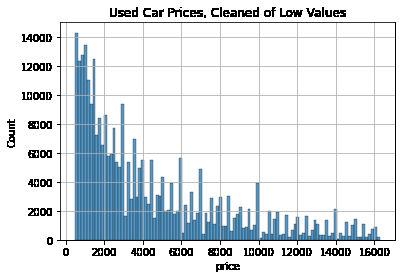

Migs Germar’s Data Science Blog - Basic Data Cleaning with eBay Car Sales Data
Гистограмма распределения цен автомобилей после очистки данных. Объясните особенности: где сосредоточены большинство объявлений, есть ли длинный хвост дорогих машин и т.д.


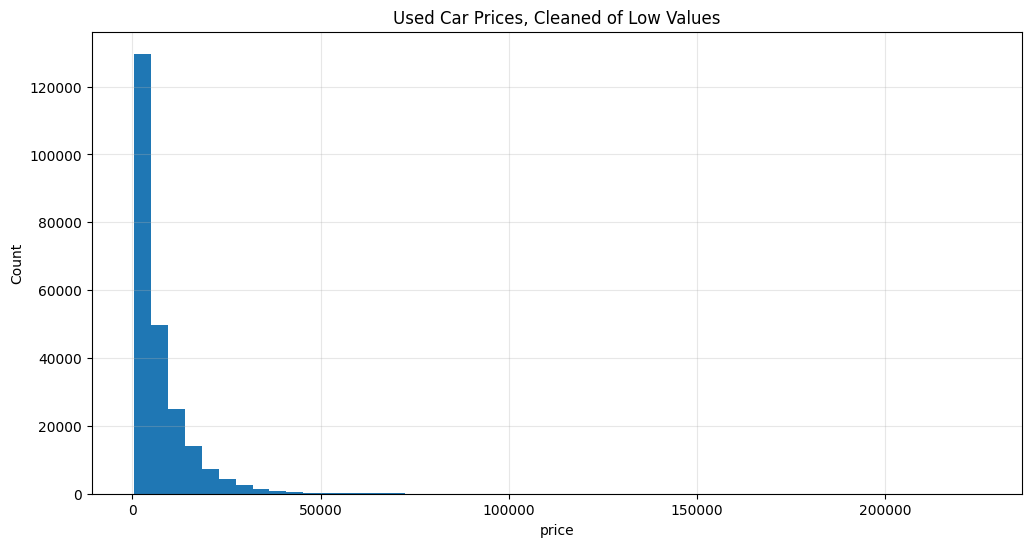

In [17]:
plt.figure(figsize=(12,6))
plt.hist(df['price'], bins=50)
plt.title('Used Car Prices, Cleaned of Low Values')
plt.xlabel('price')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

Распределение цен скорее всего экспоненциально
<br>Большинство предложений - бюджетные автомобили

16. Взаимосвязь пробега и цены: Исследуйте связь между пробегом и ценой. Постройте диаграмму рассеяния (scatterplot) с kilometer по горизонтали и price по вертикали. Оцените корреляцию: как цена падает при увеличении пробега. Сделайте выводы и при необходимости рассчитайте коэффициент корреляции.

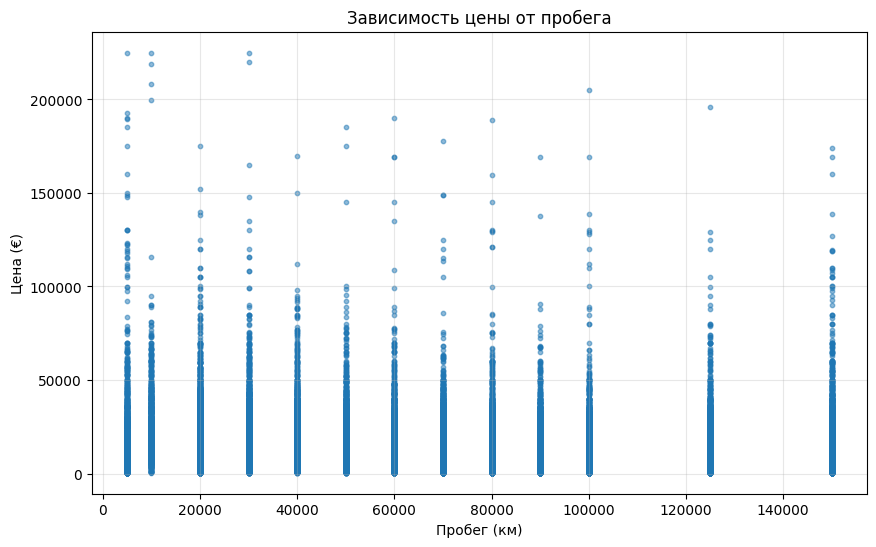

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df['kilometer'], df['price'], alpha=0.5, s=10)
plt.title('Зависимость цены от пробега')
plt.xlabel('Пробег (км)')
plt.ylabel('Цена (€)')
plt.grid(alpha=0.3)
plt.show()

Корреляция близка к нулю, это означает что в данных данных пробег не влияет на цену и другие факторы важнее

17.**Анализ по маркам**:

Посмотрите, какие марки (brand) представлены в данных. Выведите число объявлений по каждой марке (df["brand"].value_counts()), а также среднюю или медианную цену для каждой марки (df.groupby("brand")["price"].median()). Отсортируйте по убыванию цены. Это покажет, какие бренды продаются дороже в среднем.

In [19]:
df['brand'].value_counts()

df.groupby('brand')['price'].median().sort_values(ascending=False)

brand_stats = df.groupby('brand').agg({
    'price': ['count', 'median', 'mean'],
    'kilometer': 'median'
}).round(0)
brand_stats.columns = ['count', 'median_price', 'mean_price', 'median_km']
brand_stats.sort_values('median_price', ascending=False)

,count,median_price,mean_price,median_km
brand,,,,
porsche,1706,31945.0,39823.0,100000.0
land_rover,605,14500.0,18962.0,150000.0
mini,2794,9000.0,10498.0,90000.0
jeep,585,8000.0,12065.0,150000.0
jaguar,449,7600.0,13621.0,150000.0
audi,23587,7550.0,10332.0,150000.0
bmw,28875,6999.0,9438.0,150000.0
mercedes_benz,25146,5999.0,9154.0,150000.0
skoda,4352,5700.0,7213.0,125000.0


18.  В качестве **дальнейших шагов** можно проанализировать влияние года регистрации на цену (построить сводную таблицу или график «год регистрации – средняя цена»), сравнить цены с учётом наличия повреждений (not_repaired_damage) и т.д.

Для каждой гипотезы сформулируйте вопрос (например, «У каких марок автомобили самые дорогие?») и постройте соответствующую группировку или визуализацию.


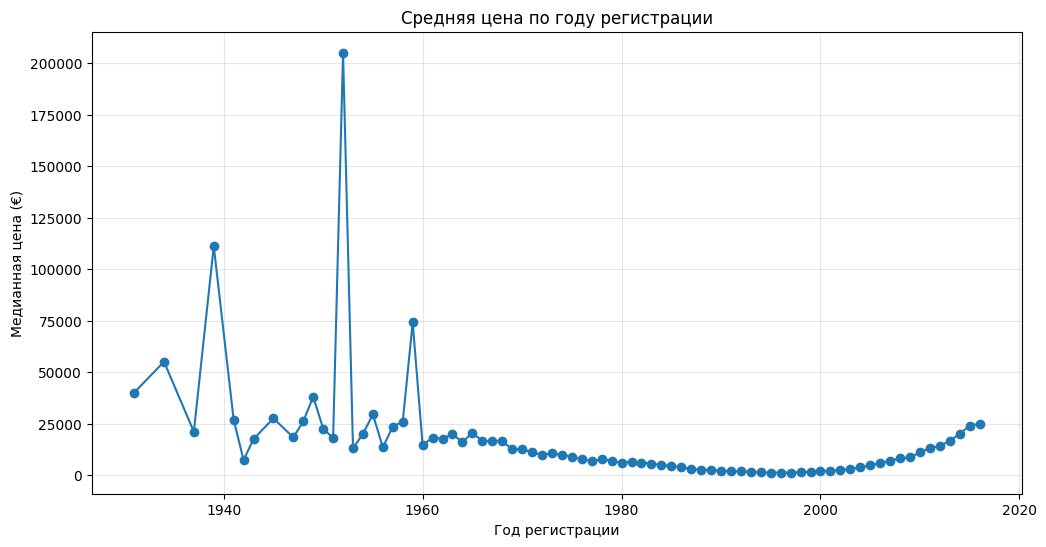

In [22]:
# 1. Влияние года регистрации на цену
year_price = df.groupby('year_of_registration')['price'].median()
plt.figure(figsize=(12, 6))
year_price.plot(kind='line', marker='o')
plt.title('Средняя цена по году регистрации')
plt.xlabel('Год регистрации')
plt.ylabel('Медианная цена (€)')
plt.grid(alpha=0.3)
plt.show()

In [23]:
# 2. Влияние повреждений (not_repaired_damage)
df.groupby('not_repaired_damage')['price'].median()

not_repaired_damage
ja      1500.0
nein    4690.0
Name: price, dtype: float64

In [25]:
# 3. Влияние типа топлива
fuel_stats = df.groupby('fuel_type').agg({
    'price': 'median',
    'kilometer': 'median'
})
print(fuel_stats)

             price  kilometer
fuel_type                    
andere      4000.0   150000.0
benzin      3100.0   150000.0
cng         4495.0   150000.0
diesel      6950.0   150000.0
elektro    11025.0    40000.0
hybrid     11799.5    70000.0
lpg         3350.0   150000.0


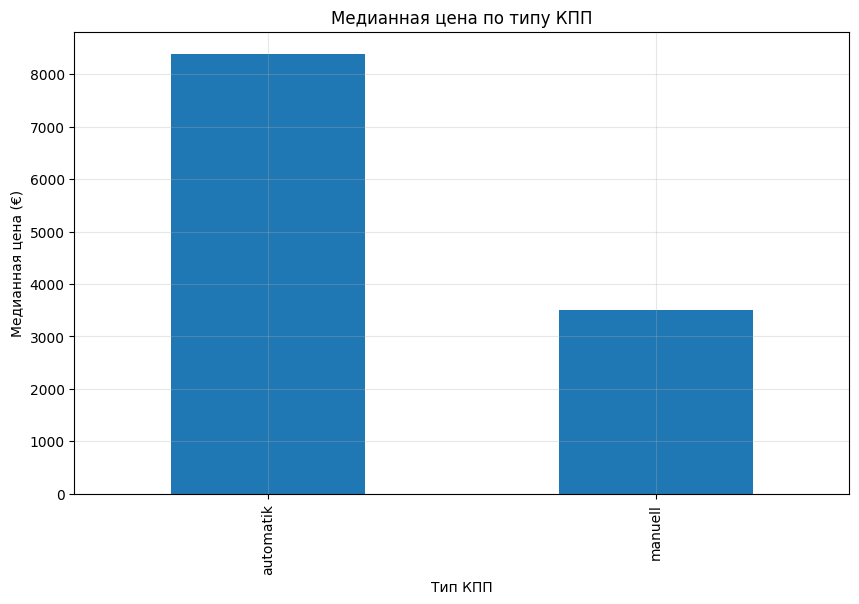

In [29]:
# 4. Влияние типа коробки передач
gearbox_stats = df.groupby('gearbox')['price'].median()
plt.figure(figsize=(10,6))
gearbox_stats.plot(kind='bar')
plt.title('Медианная цена по типу КПП')
plt.xlabel('Тип КПП')
plt.ylabel('Медианная цена (€)')
plt.grid(alpha=0.3)
plt.show()